In [99]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

In [100]:
npr.random((1,5))

array([[0.28128028, 0.16766487, 0.28089823, 0.72216933, 0.77440045]])

In [101]:
#Simulation matrices de n*p gaussiennes réelles standards

def normal_standard(n, p) : 

    U = npr.random((n,p))
    V = npr.random((n,p))

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

In [102]:
normal_standard(1,5)

array([[ 0.31365571,  0.32435485, -0.39484593, -1.20473357,  1.27427246]])

In [112]:
# Simulation d'un mouvement brownien standard
def mouvement_brownien(T, N):
    """
    Simule une trajectoire d'un mouvement brownien standard.
    Paramètres :
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - t : tableau des temps
    - W : tableau des valeurs du mouvement brownien
    """

    dt = T / N
    t = np.linspace(0, T, N+1)
    W = np.zeros(N+1)

    dW = np.sqrt(dt) * normal_standard(1, N)[0]

    for i in range(1, N+1):
        W[i] = W[i-1] + dW[i-1]

    return t, W

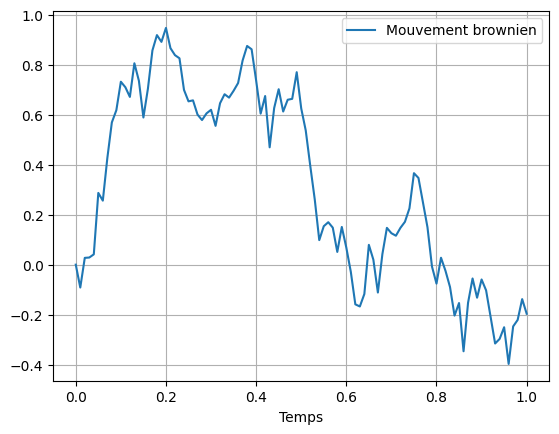

In [113]:
# Test 

t, W = mouvement_brownien(1, 100)

# Affichage
plt.plot(t, W, label='Mouvement brownien')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

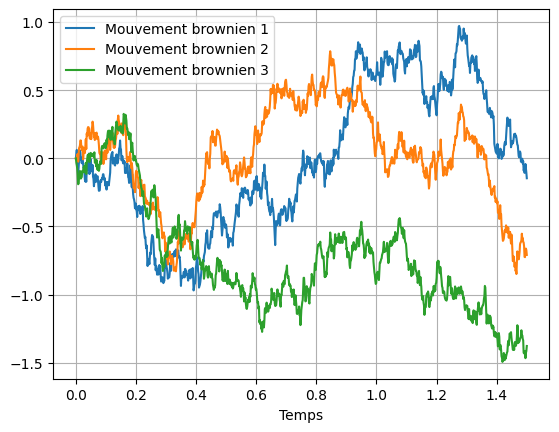

In [114]:
# Simulation des trajectoires Mouvement Bornien Standards Corrélés
T = 1.5   # Temps final
N = 1000  # Nombre de pas de temps
#rho = 0.3

def mouvement_brownien_corr(T,N,rho = 0.3) :
    Gamma = np.linalg.cholesky([[1,rho,rho],
                                [rho,1,rho],
                                [rho,rho,1]])
    # 1 : Simulation MB standards de dimension 3
    t1, W1 = mouvement_brownien(T, N)
    _, W2 = mouvement_brownien(T, N)
    _, W3 = mouvement_brownien(T, N)

    # 2 : corrélation des MB : 
    for i in range (0, N):
        [W1[i],W2[i],W3[i]] = Gamma @ [W1[i],W2[i],W3[i]]
    return W1,W2,W3

[W1,W2,W3] = mouvement_brownien_corr(T,N)
# Affichage
plt.plot(t1, W1, label='Mouvement brownien 1')
plt.plot(t1, W2, label='Mouvement brownien 2')
plt.plot(t1, W3, label='Mouvement brownien 3')
plt.xlabel('Temps')
plt.legend()
plt.grid()
plt.show()

Text(0.5, 0, 'W3(T)')

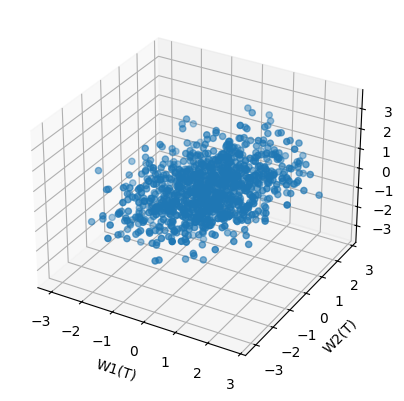

In [116]:
# Simulation du vecteur gaussien (W1(T), W2(T), W3(T)), centré, de matrice de var-cov Gamma
N = 1000
W=normal_standard(3, N)

rho = 0.3
Gamma = [[1,rho,rho],
         [rho,1,rho],
         [rho,rho,1]]

A = np.linalg.cholesky(Gamma)

B = A @ W 

fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(B[0], B[1], B[2])

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')


In [117]:
# Simulation de P1 par la méthode de Monte Carlo

def LGN_uniforme(N) :
    """
    Simule l'esperance d'une suite de v.a. iid.
    Paramètres :
    - X : vecteur de v.a. 
    - T : temps final
    - N : nombre de pas de temps

    Retourne :
    - E : Esperance des (Xi)i à une précision 1/sqrt(N)
    """

    U = np.random.uniform(0, 1, N) # génère N v.a. uniformes sur [0,1] (à priori iid)

    return (1/N) * np.sum(U)

In [118]:
# test
N = 10000000
LGN_uniforme(N)

# on a bien une précision à ~10^-4 :DD

np.float64(0.4999192000687745)

In [124]:
def S(T, N = N, K = 1, r = 0.02, S0 = [1,1,1], sigma = [0.3,0.3,0.3] ):
    """
    Simule la solution de l'EDS de Black Scholes
    Paramètres :
    - T : temps 
    - N : nombre de pas de temps
    - K : strike de l'option (constante)
    - r : taux d'intérêt
    - S0 : conditions initiales vecteur de dim 3
    - sigma : vecteur de volatilités

    - W : mouvement brownien standards corrélés

    Retourne :
    - S : Solution de l'EDS
    """
    [W1,W2,W3] = mouvement_brownien_corr(N,T)

    S1 = S0[0] * exp((r - (1/2)*(sigma[0])^2)*T + sigma[0]*W1)
    S2 = S0[1] * exp((r - (1/2)*(sigma[1])^2)*T + sigma[1]*W2)
    S3 = S0[2] * exp((r - (1/2)*(sigma[2])^2)*T + sigma[2]*W3)

    return [S1,S2,S3]